# Step 50c — Model C on POWERGRID (extension of #50/#50b)

Same eta0=1 vs eta0=0.01 comparison as #50b, applied to the actual fv2 use case: POWERGRID,
11 years of DS3 data instead of ~5.6 years of BTC. Motivation: the BTC replication's
"eta0=1 needs ~3 years to become profitable" pattern was observed on a single, non-independent
stretch of data (908 post-breakeven ticks) — not strong evidence of a repeatable mechanism.
POWERGRID's longer history gives `eta0=1` more time to prove (or fail to prove) the same
slow-learn-then-edge pattern, and lets `eta0=0.01` be tested the same way.

**Tick = 1 trading day**, resampled from DS3's 5-min POWERGRID bars (last close of each day) —
directly comparable to the BTC replication's daily-tick setup, per DS3-only convention
(CLAUDE.md: intraday_5min_DS3 is the only permitted historical source, no CSV fallback).

Feature/target, same as BTC: `close_log_return_lag_1` → predict `close_log_return`.
Same Model C config: `epsilon=0.0002`, `penalty=None`, `learning_rate="pa1"`, `random_state=69`.

No fv2 strategy applied yet — this notebook is pure Model C replication + the 3-way
equity/drawdown comparison (eta0=1 / eta0=0.01 / raw POWERGRID buy-and-hold). fv2 strategy
integration is a deliberate next step, after this analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')

DS3_PATH = '../../../../data/historical/intraday_5min_DS3/POWERGRID.parquet'
pg_5min = pd.read_parquet(DS3_PATH)
pg_5min['date'] = pg_5min['datetime'].dt.date

# Resample DS3 5-min bars to one daily close per trading day (last bar of each session).
pg_daily = pg_5min.groupby('date')['close'].last().to_frame()
pg_daily.index = pd.to_datetime(pg_daily.index)
pg_daily = pg_daily.sort_index()

pg_daily['close_log_return'] = np.log(pg_daily['close'] / pg_daily['close'].shift())
pg_daily['close_log_return_lag_1'] = pg_daily['close_log_return'].shift()

print('trading days:', len(pg_daily), '  date range:', pg_daily.index.min().date(), '->', pg_daily.index.max().date())
pg_daily.head()

trading days: 2810   date range: 2015-02-02 -> 2026-07-31


,close,close_log_return,close_log_return_lag_1
date,,,
2015-02-02,79.45,NaN,NaN
2015-02-03,79.20,-0.003152,NaN
2015-02-04,78.70,-0.006333,-0.003152
2015-02-05,76.90,-0.023137,-0.006333
2015-02-06,77.80,0.011636,-0.023137


In [2]:
pg_clean = pg_daily.dropna()

X_stream = pg_clean[['close_log_return_lag_1']].to_numpy()
y_stream = pg_clean['close_log_return'].to_numpy()
print('n rows in stream:', len(X_stream))
print('date range used:', pg_clean.index.min().date(), '->', pg_clean.index.max().date())

n rows in stream: 2808
date range used: 2015-02-04 -> 2026-07-31


In [3]:
def run_replication(eta0):
    model = SGDRegressor(loss="epsilon_insensitive", epsilon=0.0002, penalty=None,
                          learning_rate="pa1", eta0=eta0, random_state=69)
    scaler = StandardScaler()
    rows = []
    for t in range(len(X_stream)):
        X_t = X_stream[t].reshape(1, -1)
        y_t = np.array([y_stream[t]])
        scaler.partial_fit(X_t)
        X_t_scaled = scaler.transform(X_t)
        pred_y = 0.0 if t == 0 else model.predict(X_t_scaled)[0]
        model.partial_fit(X_t_scaled, y_t)
        signal = np.sign(pred_y)
        rows.append({'tick': t, 'w': model.coef_[0], 'b': model.intercept_[0],
                      'sig': signal, 'true_y': y_t[0], 'trade_log_return': signal * y_t[0]})
    df = pd.DataFrame(rows).set_index('tick')
    # trade_log_return is structurally 0 on warmup ticks (signal=0), so a plain cumsum
    # naturally carries the running total forward with no gaps.
    df['cum'] = df['trade_log_return'].cumsum()
    return df

df_eta1 = run_replication(eta0=1)
df_eta001 = run_replication(eta0=0.01)
df_eta2 = run_replication(eta0=2)  # best performer from the eta0 sweep (+0.692 final return)

raw_pg_cum = pd.Series(y_stream, index=range(len(y_stream))).cumsum()
raw_pg_cum.index.name = 'tick'

def drawdown(cum_series):
    return cum_series - cum_series.cummax()

curves = [
    ('eta0=1 (Model C)', df_eta1['cum'], '#e67e22'),
    ('eta0=0.01 (Model C)', df_eta001['cum'], '#2ecc71'),
    ('eta0=2.0 (Model C, sweep best)', df_eta2['cum'], '#c471ed'),
    ('Raw POWERGRID buy-and-hold', raw_pg_cum, '#4a90d9'),
]

for label, cum, _ in curves:
    print(f'{label}: final cum return = {cum.iloc[-1]:.4f}   max drawdown = {drawdown(cum).min():.4f}')

eta0=1 (Model C): final cum return = -0.9470   max drawdown = -1.6530
eta0=0.01 (Model C): final cum return = -0.7265   max drawdown = -1.4329
eta0=2.0 (Model C, sweep best): final cum return = 0.6915   max drawdown = -0.6353
Raw POWERGRID buy-and-hold: final cum return = 1.2770   max drawdown = -0.4401


### Equity curves — eta0=1, eta0=0.01, eta0=2.0, raw POWERGRID — stacked

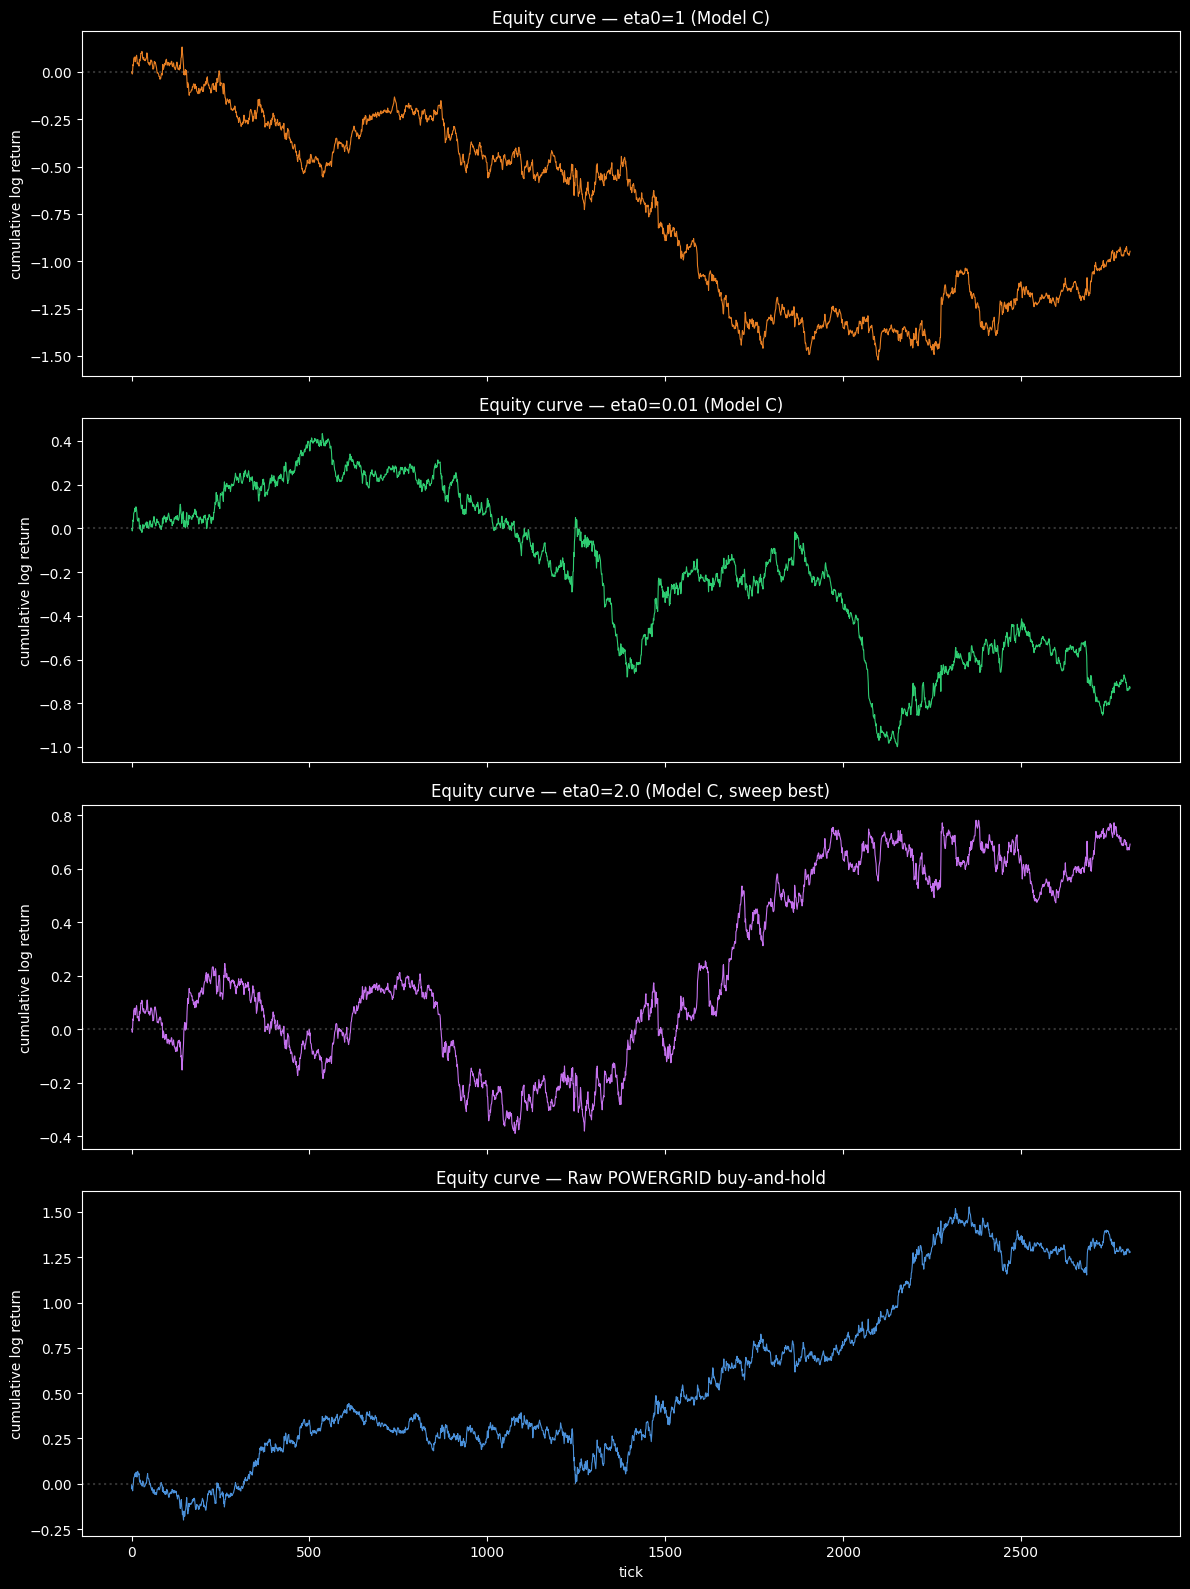

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for ax, (label, cum, color) in zip(axes, curves):
    ax.plot(cum.index, cum, color=color, linewidth=0.8)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(f'Equity curve — {label}')
    ax.set_ylabel('cumulative log return')

axes[-1].set_xlabel('tick')
plt.tight_layout()
plt.show()

### Drawdown curves — eta0=1, eta0=0.01, eta0=2.0, raw POWERGRID — stacked

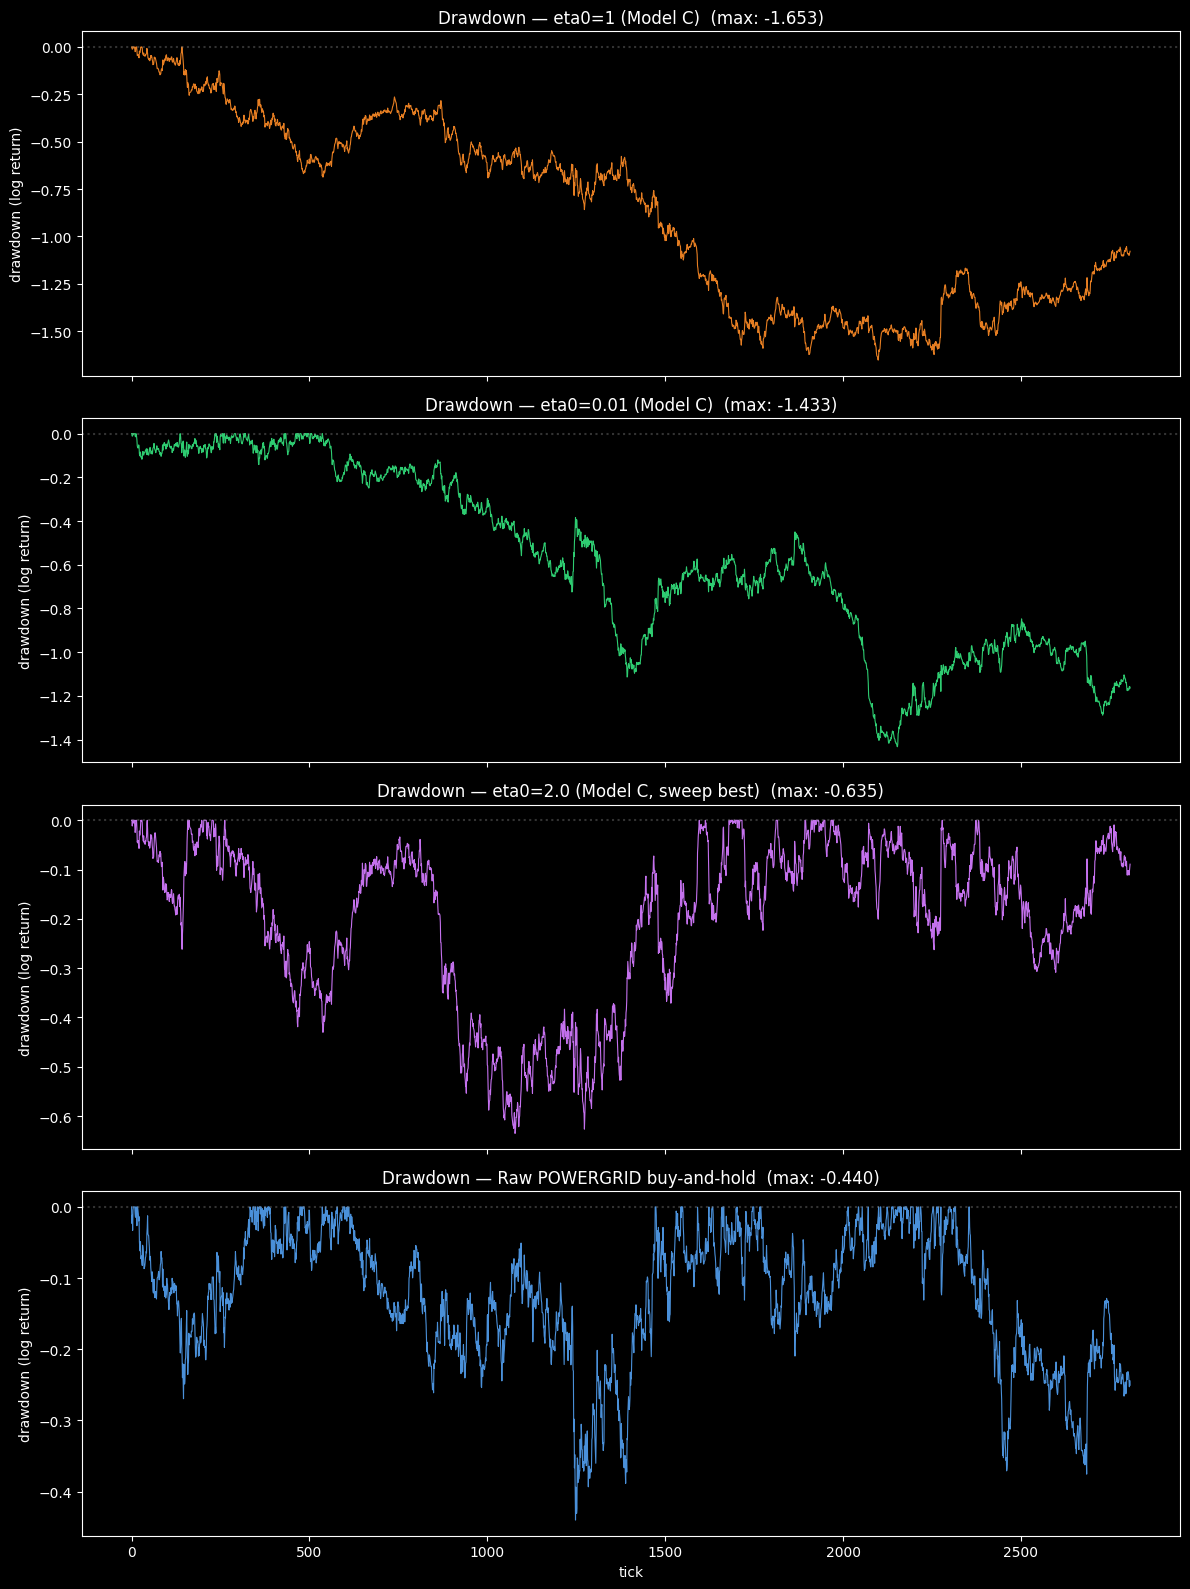

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for ax, (label, cum, color) in zip(axes, curves):
    dd = drawdown(cum)
    ax.plot(dd.index, dd, color=color, linewidth=0.8)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(f'Drawdown — {label}  (max: {dd.min():.3f})')
    ax.set_ylabel('drawdown (log return)')

axes[-1].set_xlabel('tick')
plt.tight_layout()
plt.show()